# Sessions Inventory: Analysis & Statistics

Built for the actual `sessions_inventory.json` schema: a **list of session records**, each with
scalar fields (`session_id`, `session_date`, `child_id`, `session_type`, `session_number`) plus
**nested file-listing fields** (`all_files`, `all_folders`, `mkv_files`, `audio_files`,
`json_files`, `eaf_files`, `txt_files`, `folder_structure`) and explicit availability flags
(`bounding_boxes_folder_available`, `skeletons_folder_available`,
`visualizations_folder_available`, `config_reid_json_available`).

**Project:** CHUV-ADHD Art Therapy  

In [1]:
import json
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Global Display & Plot Configurations
JSON_PATH = "sessions_inventory.json"
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
plt.style.use("ggplot")
plt.rcParams.update({"font.size": 10, "figure.titlesize": 14})

In [2]:
# ==========================================
# 1. HELPER FUNCTIONS
# ==========================================
def canonicalize_child_id(child_id_str):
    """Normalizes group IDs (e.g., '10-17' and '17-10' -> '10-17')."""
    if pd.isna(child_id_str) or not isinstance(child_id_str, str):
        return np.nan
    ids = re.findall(r"\d+", child_id_str)
    return "-".join(map(str, sorted(map(int, ids)))) if len(ids) > 1 else child_id_str


def parse_session_date(date_str):
    """Parses session dates supporting multiple string formats."""
    if pd.isna(date_str):
        return pd.NaT
    for fmt in ("%Y-%m-%d", "%d-%m-%Y", "%Y/%m/%d", "%d/%m/%Y"):
        try:
            return pd.to_datetime(date_str, format=fmt)
        except ValueError:
            continue
    return pd.to_datetime(date_str, errors="coerce")


def classify_participant_type(child_id_str):
    """Distinguishes individual subjects from group interactions."""
    if pd.isna(child_id_str):
        return "Unknown"
    ids = re.findall(r"\d+", str(child_id_str))
    return "Group" if len(ids) > 1 else "Individual"


def assign_usability_tier(row):
    """Categorizes sessions based on available data modalities."""
    has_video = row.get("n_mkv_files", 0) > 0
    has_audio = row.get("n_audio_files", 0) > 0
    has_eaf = row.get("n_eaf_files", 0) > 0
    has_skeletons = bool(row.get("skeletons_folder_available", False))

    if has_video and has_audio and has_eaf and has_skeletons:
        return "Full Stack (Video+Audio+EAF+Skeletons)"
    elif has_video and has_eaf:
        return "Annotated Videos"
    elif has_video:
        return "Raw Video Only"
    else:
        return "Missing Video"


In [3]:
# ==========================================
# 2. DATA LOADING & CLEANING
# ==========================================
with open(JSON_PATH, "r", encoding="utf-8") as f:
    df = pd.DataFrame(json.load(f))

df_clean = df.copy()

df_clean.rename(
    columns={"Visualizations_folder_available": "visualizations_folder_available"},
    inplace=True,
)

if "child_id" in df_clean.columns:
    df_clean["child_id_canonical"] = df_clean["child_id"].apply(
        canonicalize_child_id
    )

nested_list_cols = [
    "all_files",
    "all_folders",
    "mkv_files",
    "audio_files",
    "json_files",
    "eaf_files",
    "txt_files",
]
for col in nested_list_cols:
    if col in df_clean.columns:
        df_clean[f"n_{col}"] = df_clean[col].apply(
            lambda x: len(x) if isinstance(x, list) else 0
        )

bool_cols = [col for col in df_clean.columns if "available" in col.lower()]
df_clean[bool_cols] = df_clean[bool_cols].fillna(False).astype(bool)

df_clean = df_clean.sort_values(
    by="n_txt_files" if "n_txt_files" in df_clean.columns else "session_id",
    ascending=False,
).drop_duplicates(subset=["session_id"], keep="first")

if "session_date" in df_clean.columns:
    df_clean["session_date"] = df_clean["session_date"].apply(
        parse_session_date
    )
    df_clean["year_month"] = df_clean["session_date"].dt.to_period("M").astype(str)

df_clean["participant_type"] = df_clean["child_id_canonical"].apply(
    classify_participant_type
)
df_clean["usability_tier"] = df_clean.apply(assign_usability_tier, axis=1)
df_clean["is_annotated"] = df_clean["n_eaf_files"] > 0
df_clean["session_num"] = pd.to_numeric(
    df_clean.get("session_number", pd.Series()), errors="coerce"
)

# Pipeline Flags
df_clean["has_video"] = df_clean["n_mkv_files"] > 0
df_clean["has_bboxes"] = df_clean.get(
    "bounding_boxes_folder_available", pd.Series(False, index=df_clean.index)
)
df_clean["has_skeletons"] = df_clean.get(
    "skeletons_folder_available", pd.Series(False, index=df_clean.index)
)
df_clean["has_reid_config"] = df_clean.get(
    "config_reid_json_available", pd.Series(False, index=df_clean.index)
)
df_clean["pipeline_ready"] = (
    df_clean["has_video"]
    & df_clean["has_bboxes"]
    & df_clean["has_skeletons"]
    & df_clean["has_reid_config"]
)
df_clean["readiness_score"] = (
    df_clean["has_video"].astype(int)
    + df_clean["has_bboxes"].astype(int)
    + df_clean["has_skeletons"].astype(int)
    + df_clean["has_reid_config"].astype(int)
)

In [9]:
df_clean.head()

,session_id,session_date,child_id,session_type,session_number,folder_structure,all_files,all_folders,mkv_files,audio_files,json_files,eaf_files,txt_files,bounding_boxes_folder_available,skeletons_folder_available,visualizations_folder_available,config_reid_json_available,child_id_canonical,n_all_files,n_all_folders,n_mkv_files,n_audio_files,n_json_files,n_eaf_files,n_txt_files,year_month,participant_type,usability_tier,is_annotated,session_num,has_video,has_bboxes,has_skeletons,has_reid_config,pipeline_ready,readiness_score
227,9-11-2023_#1_GROUP_[3-1],2023-11-09,3-1,GROUP,1,"{'files': ['audio.wav', 'camera_a.mkv', 'camer...","[audio.wav, camera_a.mkv, camera_a_with_ids_op...","[bounding_boxes, 9-11-2023_#1_GROUP_[3-1], cam...","[camera_a.mkv, camera_b.mkv]","[audio.wav, Session 6 gr 1-3 11012024.m4a]","[config_reid.json, metadata.json, patch_0_fram...",[],"[boxes_10001.txt, boxes_10013.txt, boxes_10003...",True,True,False,True,1-3,14808,6,2,2,2886,0,11917,2023-11,Group,Raw Video Only,False,1.0,True,True,True,True,True,4
3,10-1-2024_#6_INDIVIDUAL_[15],2024-01-10,15,INDIVIDUAL,6,{'files': ['10-1-2024_#6_INDIVIDUAL_(15)_WAKEE...,[10-1-2024_#6_INDIVIDUAL_(15)_WAKEE_02.02.26_B...,"[bounding_boxes, 10-1-2024_#6_INDIVIDUAL_[15],...","[camera_a.mkv, camera_b.mkv]","[audio.wav, Session6 ind 15 100123 (1).m4a]","[config_reid.json, metadata.json, patch_0_fram...",[10-1-2024_#6_INDIVIDUAL_(15)_WAKEE_02.02.26_B...,[10-1-2024_#6_INDIVIDUAL_(15)_WAKEE_02.02.26_B...,True,True,False,True,15,12624,6,2,2,1243,3,11371,2024-01,Individual,Full Stack (Video+Audio+EAF+Skeletons),True,6.0,True,True,True,True,True,4
9,11-1-2024_#9_INDIVIDUAL_[18],2024-01-11,18,INDIVIDUAL,9,{'files': ['11-1-2024_#9_INDIVIDUAL_(18)_WAKEE...,[11-1-2024_#9_INDIVIDUAL_(18)_WAKEE_03.02.26_B...,"[bounding_boxes, 11-1-2024_#9_INDIVIDUAL_[18],...","[camera_a.mkv, camera_b.mkv]","[audio.wav, Ind 18 session 9 -11012024.m4a]","[config_reid.json, config_reid_ids.json, metad...",[11-1-2024_#9_INDIVIDUAL_(18)_WAKEE_03.02.26_B...,[11-1-2024_#9_INDIVIDUAL_(18)_WAKEE_03.02.26_B...,True,True,False,True,18,12295,6,2,2,1126,2,11160,2024-01,Individual,Full Stack (Video+Audio+EAF+Skeletons),True,9.0,True,True,True,True,True,4
18,12-6-2024_#22_INDIVIDUAL_[12],2024-06-12,12,INDIVIDUAL,22,"{'files': ['camera_a.mkv', 'camera_a_with_ids_...","[camera_a.mkv, camera_a_with_ids_openpose.mp4,...","[bounding_boxes, 12-6-2024_#22_INDIVIDUAL_[12]...","[camera_a.mkv, camera_b.mkv]","[Session 22 part 12 (1).m4a, Session 22 part 1...","[config_reid.json, metadata.json]",[],"[boxes_10000.txt, boxes_10003.txt, boxes_10002...",True,True,False,True,12,10995,6,2,2,2,0,10988,2024-06,Individual,Raw Video Only,False,22.0,True,True,True,True,True,4
218,8-5-2024_#18_INDIVIDUAL_[12],2024-05-08,12,INDIVIDUAL,18,{'files': ['8-5-2024_#18_INDIVIDUAL_(12)_WAKEE...,[8-5-2024_#18_INDIVIDUAL_(12)_WAKEE_14.08.25_B...,"[bounding_boxes, 8-5-2024_#18_INDIVIDUAL_[12],...","[camera_a.mkv, camera_b.mkv]",[Session 18 part 12.m4a],"[config_reid.json, metadata.json, patch_0_fram...",[8-5-2024_#18_INDIVIDUAL_(12)_WAKEE_14.08.25_B...,[8-5-2024_#18_INDIVIDUAL_(12)_WAKEE_14.08.25_B...,True,True,True,True,12,5082,7,2,1,1670,1,3402,2024-05,Individual,Full Stack (Video+Audio+EAF+Skeletons),True,18.0,True,True,True,True,True,4


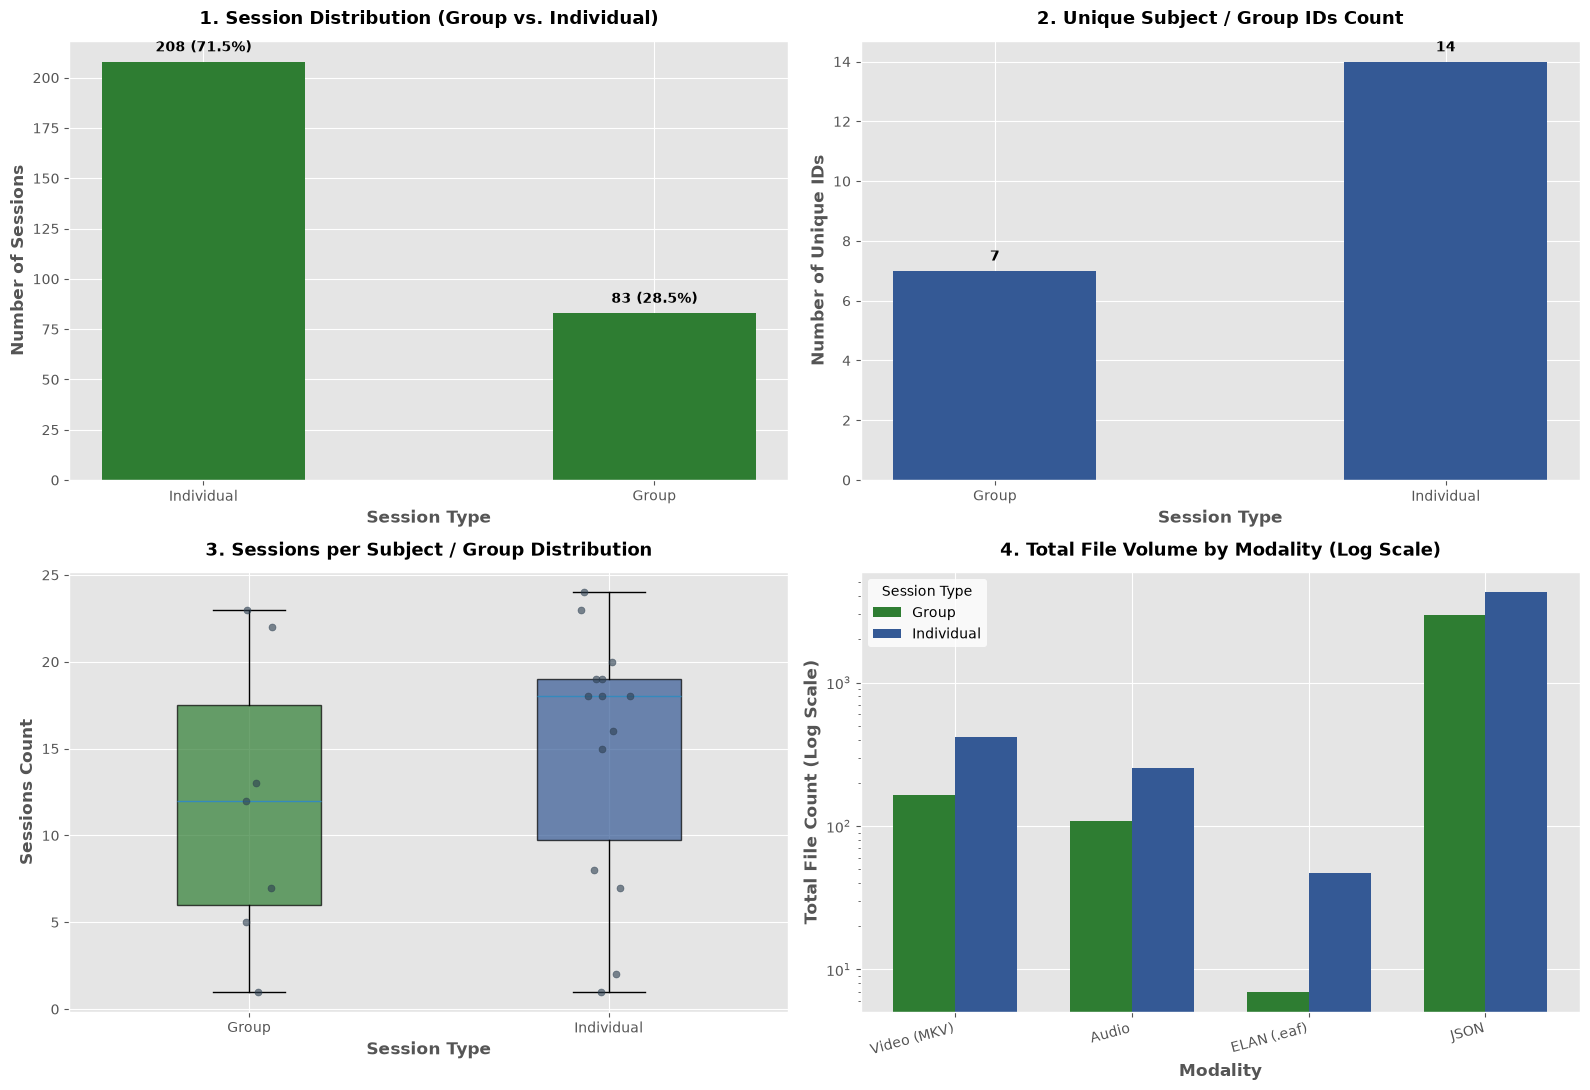

In [4]:
# ==========================================
# 3. DASHBOARD 1: PARTICIPANTS & MODALITIES
# ==========================================
colors = ["#2E7D32", "#345995", "#E67E22", "#C0392B"]
fig2, axes2 = plt.subplots(2, 2, figsize=(16, 11))

# Panel 1: Session Distribution
counts = df_clean["participant_type"].value_counts()
bars1 = axes2[0, 0].bar(counts.index, counts.values, color=colors[0], width=0.45)
axes2[0, 0].set_title(
    "1. Session Distribution (Group vs. Individual)", fontweight="bold", fontsize=13, pad=12
)
axes2[0, 0].set_xlabel("Session Type", fontweight="bold")
axes2[0, 0].set_ylabel("Number of Sessions", fontweight="bold")

for bar in bars1:
    h = bar.get_height()
    pct = (h / len(df_clean)) * 100
    axes2[0, 0].annotate(
        f"{int(h)} ({pct:.1f}%)",
        (bar.get_x() + bar.get_width() / 2.0, h),
        ha="center",
        va="bottom",
        xytext=(0, 5),
        textcoords="offset points",
        fontweight="bold",
        fontsize=10,
    )

# Panel 2: Unique IDs
type_counts = df_clean.groupby("participant_type")["child_id_canonical"].nunique()
bars2 = axes2[0, 1].bar(
    type_counts.index, type_counts.values, color=colors[1], width=0.45
)
axes2[0, 1].set_title(
    "2. Unique Subject / Group IDs Count", fontweight="bold", fontsize=13, pad=12
)
axes2[0, 1].set_xlabel("Session Type", fontweight="bold")
axes2[0, 1].set_ylabel("Number of Unique IDs", fontweight="bold")

for bar in bars2:
    h = bar.get_height()
    axes2[0, 1].annotate(
        f"{int(h)}",
        (bar.get_x() + bar.get_width() / 2.0, h),
        ha="center",
        va="bottom",
        xytext=(0, 5),
        textcoords="offset points",
        fontweight="bold",
        fontsize=10,
    )

# Panel 3: Sessions Boxplot with Jitter
sessions_per_subject = (
    df_clean.groupby(["participant_type", "child_id_canonical"])
    .size()
    .reset_index(name="session_count")
)
cats = sessions_per_subject["participant_type"].unique()
data_to_plot = [
    sessions_per_subject[sessions_per_subject["participant_type"] == c][
        "session_count"
    ]
    for c in cats
]

bp = axes2[1, 0].boxplot(data_to_plot, tick_labels=cats, patch_artist=True, widths=0.4)
for patch, color in zip(bp["boxes"], colors[: len(cats)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

np.random.seed(42)
for i, cat in enumerate(cats):
    y = sessions_per_subject[sessions_per_subject["participant_type"] == cat][
        "session_count"
    ]
    x_jitter = np.random.normal(i + 1, 0.04, size=len(y))
    axes2[1, 0].scatter(x_jitter, y, color="#2C3E50", alpha=0.6, s=25, zorder=3)

axes2[1, 0].set_title(
    "3. Sessions per Subject / Group Distribution", fontweight="bold", fontsize=13, pad=12
)
axes2[1, 0].set_xlabel("Session Type", fontweight="bold")
axes2[1, 0].set_ylabel("Sessions Count", fontweight="bold")

# Panel 4: Modality Volume Log Scale
modality_cols = ["n_mkv_files", "n_audio_files", "n_eaf_files", "n_json_files"]
modality_labels = {
    "n_mkv_files": "Video (MKV)",
    "n_audio_files": "Audio",
    "n_eaf_files": "ELAN (.eaf)",
    "n_json_files": "JSON",
}
grouped_sum = (
    df_clean.groupby("participant_type")[modality_cols]
    .sum()
    .rename(columns=modality_labels)
)
mods = list(modality_labels.values())
ptypes = grouped_sum.index.tolist()

x = np.arange(len(mods))
width = 0.35
for i, p_type in enumerate(ptypes):
    offset = (i - len(ptypes) / 2 + 0.5) * width
    axes2[1, 1].bar(
        x + offset, grouped_sum.loc[p_type], width, label=p_type, color=colors[i]
    )

axes2[1, 1].set_title(
    "4. Total File Volume by Modality (Log Scale)", fontweight="bold", fontsize=13, pad=12
)
axes2[1, 1].set_xlabel("Modality", fontweight="bold")
axes2[1, 1].set_ylabel("Total File Count (Log Scale)", fontweight="bold")
axes2[1, 1].set_xticks(x)
axes2[1, 1].set_xticklabels(mods, rotation=15, ha="right")
axes2[1, 1].set_yscale("log")
axes2[1, 1].legend(title="Session Type", facecolor="white", edgecolor="none")

plt.tight_layout()
plt.show()

In [5]:
# 4. TABLES: DISTRIBUTION OF VIDEO, AUDIO, ANNOTATIONS, BBOXES, ETC.
# ============================================================

total_sessions = len(df_clean)

# 1. Overview of modalities and resource folders
resources_data = [
    {
        "Modality / Resource": "Video (MKV)",
        "Total Count": int(df_clean["n_mkv_files"].sum()),
        "Sessions with Resource": int((df_clean["n_mkv_files"] > 0).sum()),
        "Coverage (%)": round((df_clean["n_mkv_files"] > 0).mean() * 100, 2),
        "Mean / Session": round(df_clean["n_mkv_files"].mean(), 2),
        "Median": float(df_clean["n_mkv_files"].median()),
        "Max": int(df_clean["n_mkv_files"].max())
    },
    {
        "Modality / Resource": "Audio Files",
        "Total Count": int(df_clean["n_audio_files"].sum()),
        "Sessions with Resource": int((df_clean["n_audio_files"] > 0).sum()),
        "Coverage (%)": round((df_clean["n_audio_files"] > 0).mean() * 100, 2),
        "Mean / Session": round(df_clean["n_audio_files"].mean(), 2),
        "Median": float(df_clean["n_audio_files"].median()),
        "Max": int(df_clean["n_audio_files"].max())
    },
    {
        "Modality / Resource": "ELAN Annotations (.eaf)",
        "Total Count": int(df_clean["n_eaf_files"].sum()),
        "Sessions with Resource": int((df_clean["n_eaf_files"] > 0).sum()),
        "Coverage (%)": round((df_clean["n_eaf_files"] > 0).mean() * 100, 2),
        "Mean / Session": round(df_clean["n_eaf_files"].mean(), 2),
        "Median": float(df_clean["n_eaf_files"].median()),
        "Max": int(df_clean["n_eaf_files"].max())
    },
    {
        "Modality / Resource": "JSON Files",
        "Total Count": int(df_clean["n_json_files"].sum()),
        "Sessions with Resource": int((df_clean["n_json_files"] > 0).sum()),
        "Coverage (%)": round((df_clean["n_json_files"] > 0).mean() * 100, 2),
        "Mean / Session": round(df_clean["n_json_files"].mean(), 2),
        "Median": float(df_clean["n_json_files"].median()),
        "Max": int(df_clean["n_json_files"].max())
    },
    {
        "Modality / Resource": "TXT Files",
        "Total Count": int(df_clean["n_txt_files"].sum()),
        "Sessions with Resource": int((df_clean["n_txt_files"] > 0).sum()),
        "Coverage (%)": round((df_clean["n_txt_files"] > 0).mean() * 100, 2),
        "Mean / Session": round(df_clean["n_txt_files"].mean(), 2),
        "Median": float(df_clean["n_txt_files"].median()),
        "Max": int(df_clean["n_txt_files"].max())
    },
    {
        "Modality / Resource": "Bounding Boxes (Folder)",
        "Total Count": "-",
        "Sessions with Resource": int(df_clean["bounding_boxes_folder_available"].sum()),
        "Coverage (%)": round(df_clean["bounding_boxes_folder_available"].mean() * 100, 2),
        "Mean / Session": "-",
        "Median": "-",
        "Max": "-"
    },
    {
        "Modality / Resource": "Skeletons (Folder)",
        "Total Count": "-",
        "Sessions with Resource": int(df_clean["skeletons_folder_available"].sum()),
        "Coverage (%)": round(df_clean["skeletons_folder_available"].mean() * 100, 2),
        "Mean / Session": "-",
        "Median": "-",
        "Max": "-"
    },
    {
        "Modality / Resource": "Visualizations (Folder)",
        "Total Count": "-",
        "Sessions with Resource": int(df_clean["visualizations_folder_available"].sum()),
        "Coverage (%)": round(df_clean["visualizations_folder_available"].mean() * 100, 2),
        "Mean / Session": "-",
        "Median": "-",
        "Max": "-"
    },
    {
        "Modality / Resource": "ReID Config (JSON)",
        "Total Count": "-",
        "Sessions with Resource": int(df_clean["config_reid_json_available"].sum()),
        "Coverage (%)": round(df_clean["config_reid_json_available"].mean() * 100, 2),
        "Mean / Session": "-",
        "Median": "-",
        "Max": "-"
    }
]

df_resource_summary = pd.DataFrame(resources_data)

print("\n" + "="*60)
print(" TABLE: Detailed Dataset Resource Distribution ")
print("="*60)
print(df_resource_summary.to_string(index=False))

# 2. Detailed comparative analysis: Group vs Individual
group_ind_summary = df_clean.groupby("participant_type").agg(
    Session_Count=("session_id", "count"),
    Unique_IDs=("child_id_canonical", "nunique"),
    Total_MKV=("n_mkv_files", "sum"),
    Mean_MKV=("n_mkv_files", "mean"),
    Total_Audio=("n_audio_files", "sum"),
    Mean_Audio=("n_audio_files", "mean"),
    Total_EAF=("n_eaf_files", "sum"),
    Sessions_with_EAF=("n_eaf_files", lambda x: (x > 0).sum()),
    Total_JSON=("n_json_files", "sum"),
    Sessions_with_BBoxes=("bounding_boxes_folder_available", "sum"),
    Sessions_with_Skeletons=("skeletons_folder_available", "sum"),
    Sessions_with_ReID=("config_reid_json_available", "sum")
).T

print("\n" + "="*60)
print(" TABLE: Resource Comparison (Group vs. Individual) ")
print("="*60)
print(group_ind_summary.round(2))

print("\n" + "="*60)
print(" TABLE : Children by Session Count ")
print("="*60)
if "child_id_canonical" in df_clean.columns:
    child_summary = df_clean.groupby("child_id_canonical").agg(
        session_count=("session_id", "count"),
        total_mkv=("n_mkv_files", "sum") if "n_mkv_files" in df_clean.columns else ("session_id", "count"),
        total_eaf=("n_eaf_files", "sum") if "n_eaf_files" in df_clean.columns else ("session_id", "count")
    ).sort_values(by="session_count", ascending=False)
    print(child_summary)
    
    

print("\n" + "="*60)
print(" TABLE: Child-Level Metrics ")
print("="*60)
# ==========================================
# Group by child and calculate duration, videos, and sessions
child_metrics = df_clean.groupby("child_id_canonical").agg(
    min_date=("session_date", "min"),
    max_date=("session_date", "max"),
    number_of_sessions=("session_id", "nunique"),
    total_videos=("n_mkv_files", "sum") if "n_mkv_files" in df_clean.columns else ("session_id", "count")
).reset_index()

# Calculate duration in days 
child_metrics["therapy_duration"] = (
    (child_metrics["max_date"] - child_metrics["min_date"]).dt.days + 1
).astype(int)

# Sort by Therapy Duration (days) ascending as shown in the target plot
child_metrics = child_metrics.sort_values(by="therapy_duration", ascending=True).reset_index(drop=True)

child_metrics


 TABLE: Detailed Dataset Resource Distribution 
    Modality / Resource Total Count  Sessions with Resource  Coverage (%) Mean / Session Median   Max
            Video (MKV)         582                     290         99.66            2.0    2.0     4
            Audio Files         363                     288         98.97           1.25    1.0     3
ELAN Annotations (.eaf)          54                      30         10.31           0.19    0.0     4
             JSON Files        7233                     287         98.63          24.86    1.0  2886
              TXT Files       48908                      36         12.37         168.07    0.0 11917
Bounding Boxes (Folder)           -                       5          1.72              -      -     -
     Skeletons (Folder)           -                       5          1.72              -      -     -
Visualizations (Folder)           -                       1          0.34              -      -     -
     ReID Config (JSON)          

,child_id_canonical,min_date,max_date,number_of_sessions,total_videos,therapy_duration
0,12-13,2023-11-28,2023-11-28,1,2,1
1,20,2024-01-30,2024-01-30,1,2,1
2,13,2024-06-18,2024-06-25,2,4,8
3,14-15,2023-11-15,2023-12-13,5,10,29
4,12-13-19,2023-11-07,2024-01-23,7,14,78
5,3,2024-03-21,2024-06-13,8,15,85
6,1,2024-03-21,2024-06-26,7,14,98
7,13-19,2024-01-30,2024-05-07,12,24,99
8,1-3,2023-11-09,2024-03-07,13,24,120
9,58,2024-11-14,2025-04-10,16,32,148


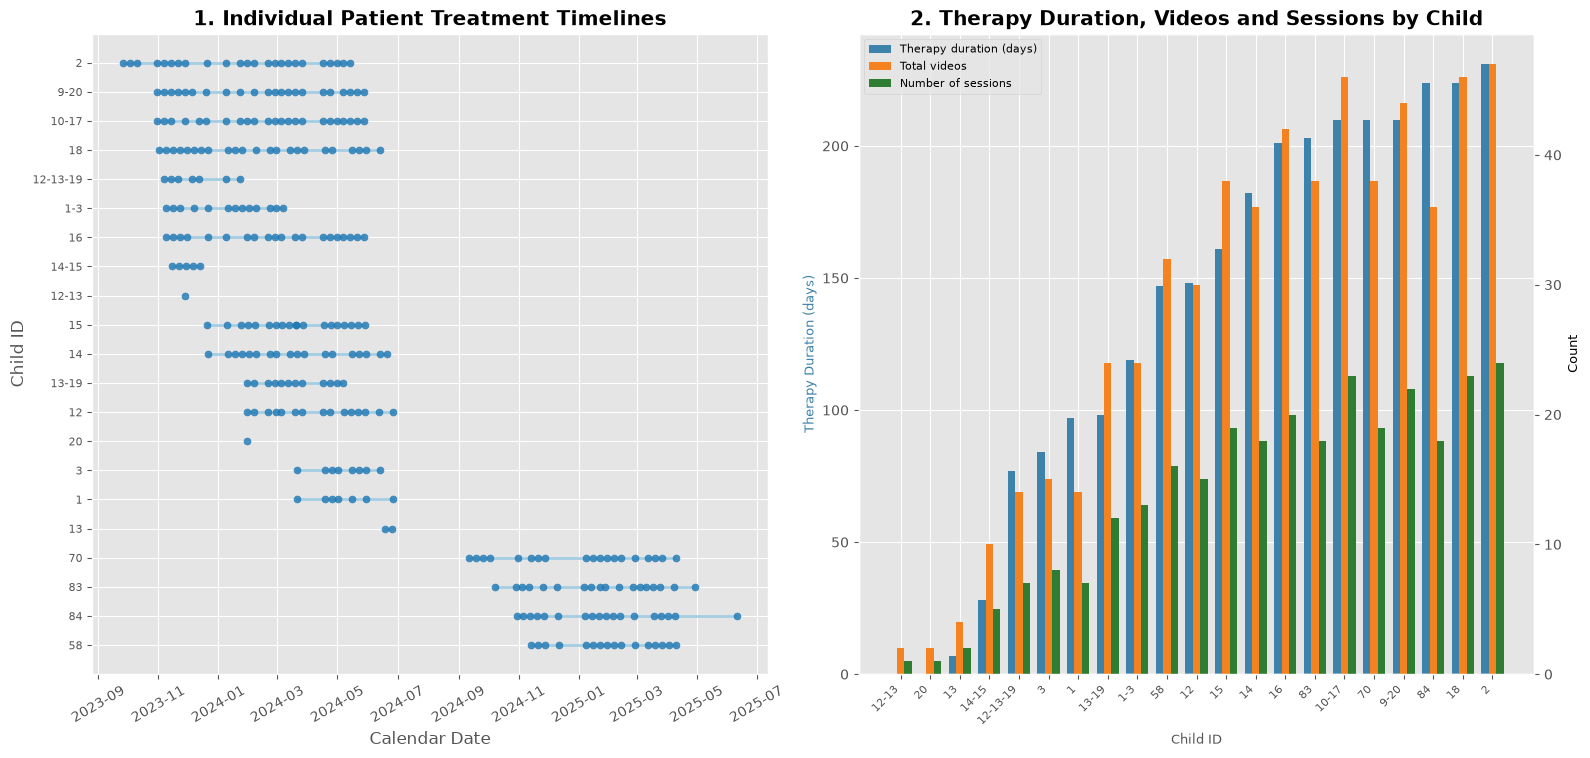

In [6]:
# ==========================================
#  5. DASHBOARD: PIPELINE & TIMELINES
# ==========================================
fig1, axes1 = plt.subplots(1, 2, figsize=(16, 8))


# Plot 1: Treatment Timelines
df_dyn = df_clean.dropna(subset=["session_date"]).copy()
child_start_dates = (
    df_dyn.groupby("child_id_canonical")["session_date"]
    .min()
    .sort_values(ascending=False)
)
ordered_children = child_start_dates.index.tolist()

ax3 = axes1[0]
for idx, child_id in enumerate(ordered_children):
    child_dates = df_dyn[df_dyn["child_id_canonical"] == child_id]["session_date"]
    ax3.plot(
        [child_dates.min(), child_dates.max()],
        [idx, idx],
        color="#a6cee3",
        linewidth=2,
        zorder=1,
    )
    ax3.scatter(
        child_dates,
        [idx] * len(child_dates),
        color="#1f78b4",
        s=25,
        alpha=0.8,
        zorder=2,
    )

ax3.set_yticks(range(len(ordered_children)))
ax3.set_yticklabels(ordered_children, fontsize=8)
ax3.set_title("1. Individual Patient Treatment Timelines", fontweight="bold")
ax3.set_xlabel("Calendar Date")
ax3.set_ylabel("Child ID")
ax3.tick_params(axis="x", rotation=30)

# Plot 2: Child Metrics
child_metrics = (
    df_clean.groupby("child_id_canonical")
    .agg(
        min_date=("session_date", "min"),
        max_date=("session_date", "max"),
        number_of_sessions=("session_id", "nunique"),
        total_videos=(
            ("n_mkv_files", "sum")
            if "n_mkv_files" in df_clean.columns
            else ("session_id", "count")
        ),
    )
    .reset_index()
)

child_metrics["therapy_duration"] = (
    (child_metrics["max_date"] - child_metrics["min_date"]).dt.days.fillna(0).astype(int)
)
child_metrics = child_metrics.sort_values(by="therapy_duration", ascending=True).reset_index(
    drop=True
)

ax4_left = axes1[1]
ax4_right = ax4_left.twinx()
x = np.arange(len(child_metrics))
width = 0.25

ax4_left.bar(
    x - width,
    child_metrics["therapy_duration"],
    width,
    label="Therapy duration (days)",
    color="#3d82ab",
)
ax4_right.bar(
    x, child_metrics["total_videos"], width, label="Total videos", color="#f58220"
)
ax4_right.bar(
    x + width,
    child_metrics["number_of_sessions"],
    width,
    label="Number of sessions",
    color="#2e7d32",
)

ax4_left.set_title(
    "2. Therapy Duration, Videos and Sessions by Child", fontweight="bold"
)
ax4_left.set_xlabel("Child ID", fontsize=9)
ax4_left.set_xticks(x)
ax4_left.set_xticklabels(
    child_metrics["child_id_canonical"], rotation=45, ha="right", fontsize=8
)
ax4_left.set_ylabel("Therapy Duration (days)", color="#3d82ab", fontsize=9)
ax4_left.set_ylim(bottom=0)

ax4_right.set_ylabel("Count", color="black", fontsize=9)
ax4_right.set_ylim(bottom=0)
ax4_right.grid(False)

lines_left, labels_left = ax4_left.get_legend_handles_labels()
lines_right, labels_right = ax4_right.get_legend_handles_labels()
ax4_left.legend(
    lines_left + lines_right, labels_left + labels_right, loc="upper left", fontsize=8
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()




✓ Loaded 291 sessions across 21 children


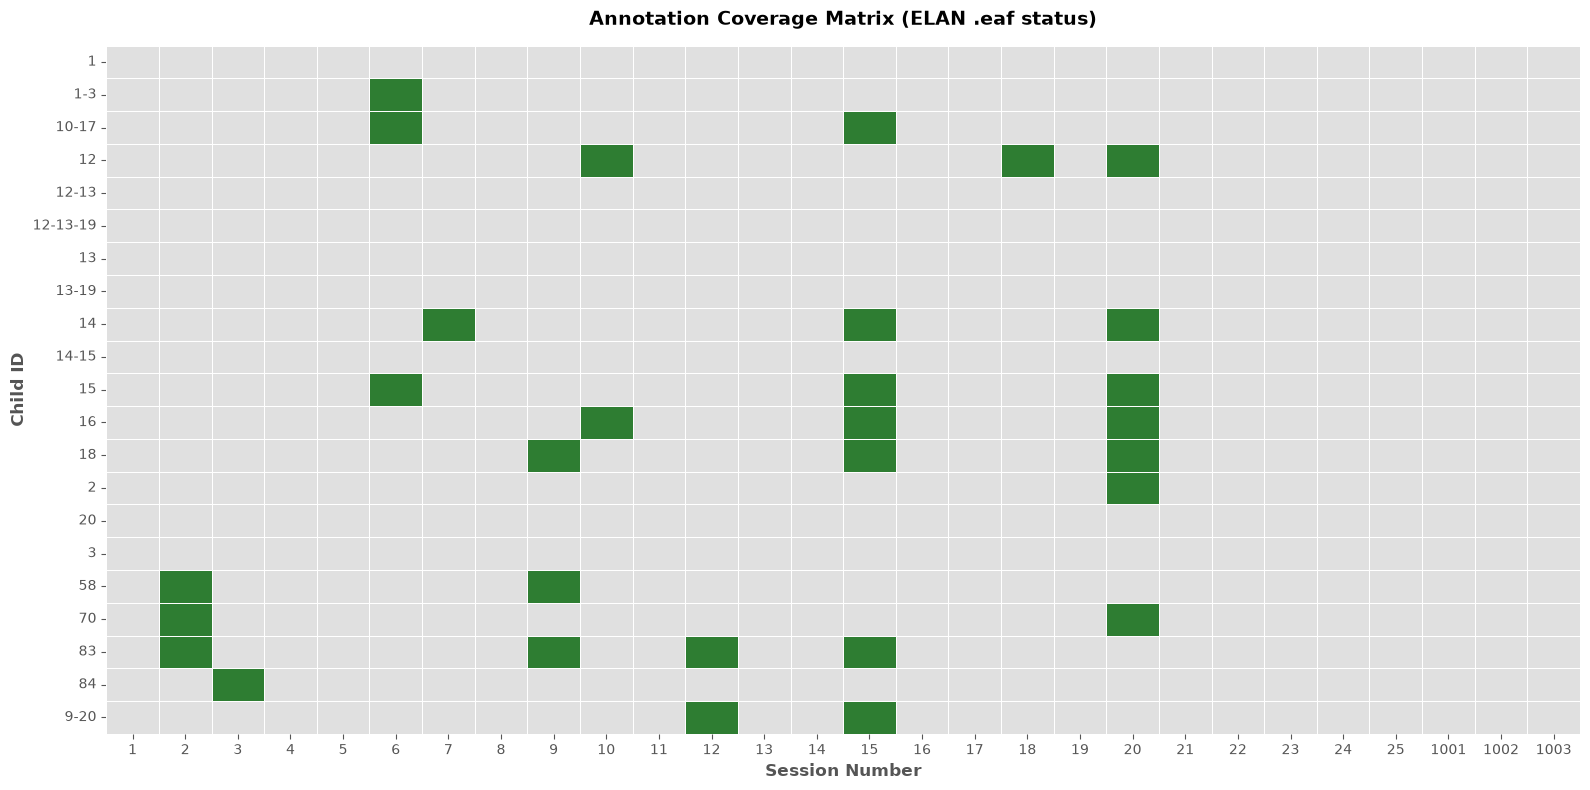


 TABLE: Gaze Shift Analysis – Early vs. Late Sessions 
Phase  Sessions  Annotated  Coverage_%  With_Video_%  With_Bboxes_%
Early       159         14        8.81         99.37           1.89
 Late       132         16       12.12        100.00           1.52


In [10]:
# ==========================================
#  6. Annotation & Gaze Shift Analysis REPORTS & TABLES
# ==========================================
print(
    f"✓ Loaded {len(df_clean)} sessions across {df_clean['child_id_canonical'].nunique()} children"
)

df_clean['is_annotated'] = df_clean['n_eaf_files'] > 0
df_clean['session_num'] = pd.to_numeric(df_clean['session_number'], errors='coerce')

annotation_matrix = pd.pivot_table(
    df_clean,
    values='is_annotated',
    index='child_id_canonical',
    columns='session_num',
    aggfunc='first',
    fill_value=False,
).astype(int)

annotation_matrix['Total_Annotated'] = annotation_matrix.sum(axis=1)
coverage_per_session = annotation_matrix.sum(axis=0)
annotation_matrix.loc['Coverage_Count'] = coverage_per_session

# 1. Annotation Coverage Matrix (Heatmap)
data_to_plot = annotation_matrix.drop(
    index="Coverage_Count", errors="ignore"
).drop(columns=["Total_Annotated"], errors="ignore")

data_to_plot.columns = [int(float(col)) for col in data_to_plot.columns]

plt.figure(figsize=(16, 8))
sns.heatmap(
    data_to_plot,
    cmap=["#e0e0e0", "#2e7d32"],  
    linewidths=0.5,
    linecolor="white",
    cbar=False,
    annot=False,
    fmt="d",  
    annot_kws={"size": 8},
)

plt.title(
    "Annotation Coverage Matrix (ELAN .eaf status)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Session Number", fontweight="bold")
plt.ylabel("Child ID", fontweight="bold")
plt.tight_layout()
plt.show()

# 2. Early vs. Late Phase Analysis 
df_clean["Min_SessionNum"] = df_clean.groupby("child_id_canonical")[
    "session_num"
].transform("min")
df_clean["Max_SessionNum"] = df_clean.groupby("child_id_canonical")[
    "session_num"
].transform("max")

df_clean["median_session_num"] = (
    df_clean["Min_SessionNum"] + df_clean["Max_SessionNum"]
) / 2

df_clean["phase"] = np.where(
    df_clean["session_num"] <= df_clean["median_session_num"], "early", "late"
)

phase_records = []
for phase_name in ["early", "late"]:
    phase_data = df_clean[df_clean["phase"] == phase_name]
    if not phase_data.empty:
        phase_records.append(
            {
                "Phase": phase_name.capitalize(),
                "Sessions": len(phase_data),
                "Annotated": int(phase_data["is_annotated"].sum()),
                "Coverage_%": round(phase_data["is_annotated"].mean() * 100, 2),
                "With_Video_%": round(
                    (phase_data["n_mkv_files"] > 0).mean() * 100, 2
                ),
                "With_Bboxes_%": round(
                    phase_data["has_bboxes"].mean() * 100, 2
                ),
            }
        )

gaze_shift = pd.DataFrame(phase_records)

print("\n" + "=" * 110)
print(" TABLE: Gaze Shift Analysis – Early vs. Late Sessions ")
print("=" * 110)
print(gaze_shift.to_string(index=False))

# 3. Pipeline Readiness Tiers
n_ready = df_clean["pipeline_ready"].sum()
pct_ready = round(n_ready / len(df_clean) * 100, 2)

readiness = pd.DataFrame(
    [
        {
            "Status": "Fully Ready (4/4)",
            "Sessions": int(df_clean["pipeline_ready"].sum()),
            "Pct": pct_ready,
        },
        {
            "Status": "3/4",
            "Sessions": int((df_clean["readiness_score"] == 3).sum()),
            "Pct": round((df_clean["readiness_score"] == 3).mean() * 100, 2),
        },
        {
            "Status": "2/4",
            "Sessions": int((df_clean["readiness_score"] == 2).sum()),
            "Pct": round((df_clean["readiness_score"] == 2).mean() * 100, 2),
        },
        {
            "Status": "1/4",
            "Sessions": int((df_clean["readiness_score"] == 1).sum()),
            "Pct": round((df_clean["readiness_score"] == 1).mean() * 100, 2),
        },
        {
            "Status": "0/4",
            "Sessions": int((df_clean["readiness_score"] == 0).sum()),
            "Pct": round((df_clean["readiness_score"] == 0).mean() * 100, 2),
        },
    ]
)
